# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [6]:
import pandas as pd
import pandas as pd
#Add the imports here
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [7]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
# Check if null values are there in the data, if yes remove it
print(df.isnull().sum())
print(df.isnull().mean() * 100)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64


In [11]:
# Identify and drop duplicate rows 
print(df.duplicated().sum())
print(f"before removing duplicated {df.shape}")
#Remove the duplicated
df=df.drop_duplicates()
print(f"After removing duplicated {df.shape}")

12
before removing duplicated (41188, 21)
After removing duplicated (41176, 21)


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [13]:
#Checking out the statistical parameters
df.describe()

#Lets check if socual and economic context attributes has any relationship with Target variables
# Convert target variable to numeric for correlation
df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})

# Check correlations
correlation = df[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_numeric']].corr()
print(f"Correlation {correlation['y_numeric']}")

#Based on the relation cons.price.idx and cons.conf.idx seems to have lowest correlationship hence lets get rid of those columns

df_clean = df.drop(['cons.price.idx','cons.conf.idx'], axis=1)
df_clean.info()


Correlation emp.var.rate     -0.298289
cons.price.idx   -0.136134
cons.conf.idx     0.054802
euribor3m        -0.307740
nr.employed      -0.354669
y_numeric         1.000000
Name: y_numeric, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           41176 non-null  int64  
 1   job           41176 non-null  object 
 2   marital       41176 non-null  object 
 3   education     41176 non-null  object 
 4   default       41176 non-null  object 
 5   housing       41176 non-null  object 
 6   loan          41176 non-null  object 
 7   contact       41176 non-null  object 
 8   month         41176 non-null  object 
 9   day_of_week   41176 non-null  object 
 10  duration      41176 non-null  int64  
 11  campaign      41176 non-null  int64  
 12  pdays         41176 non-null  int64  
 13  previous      41176 non-null  int64  
 1

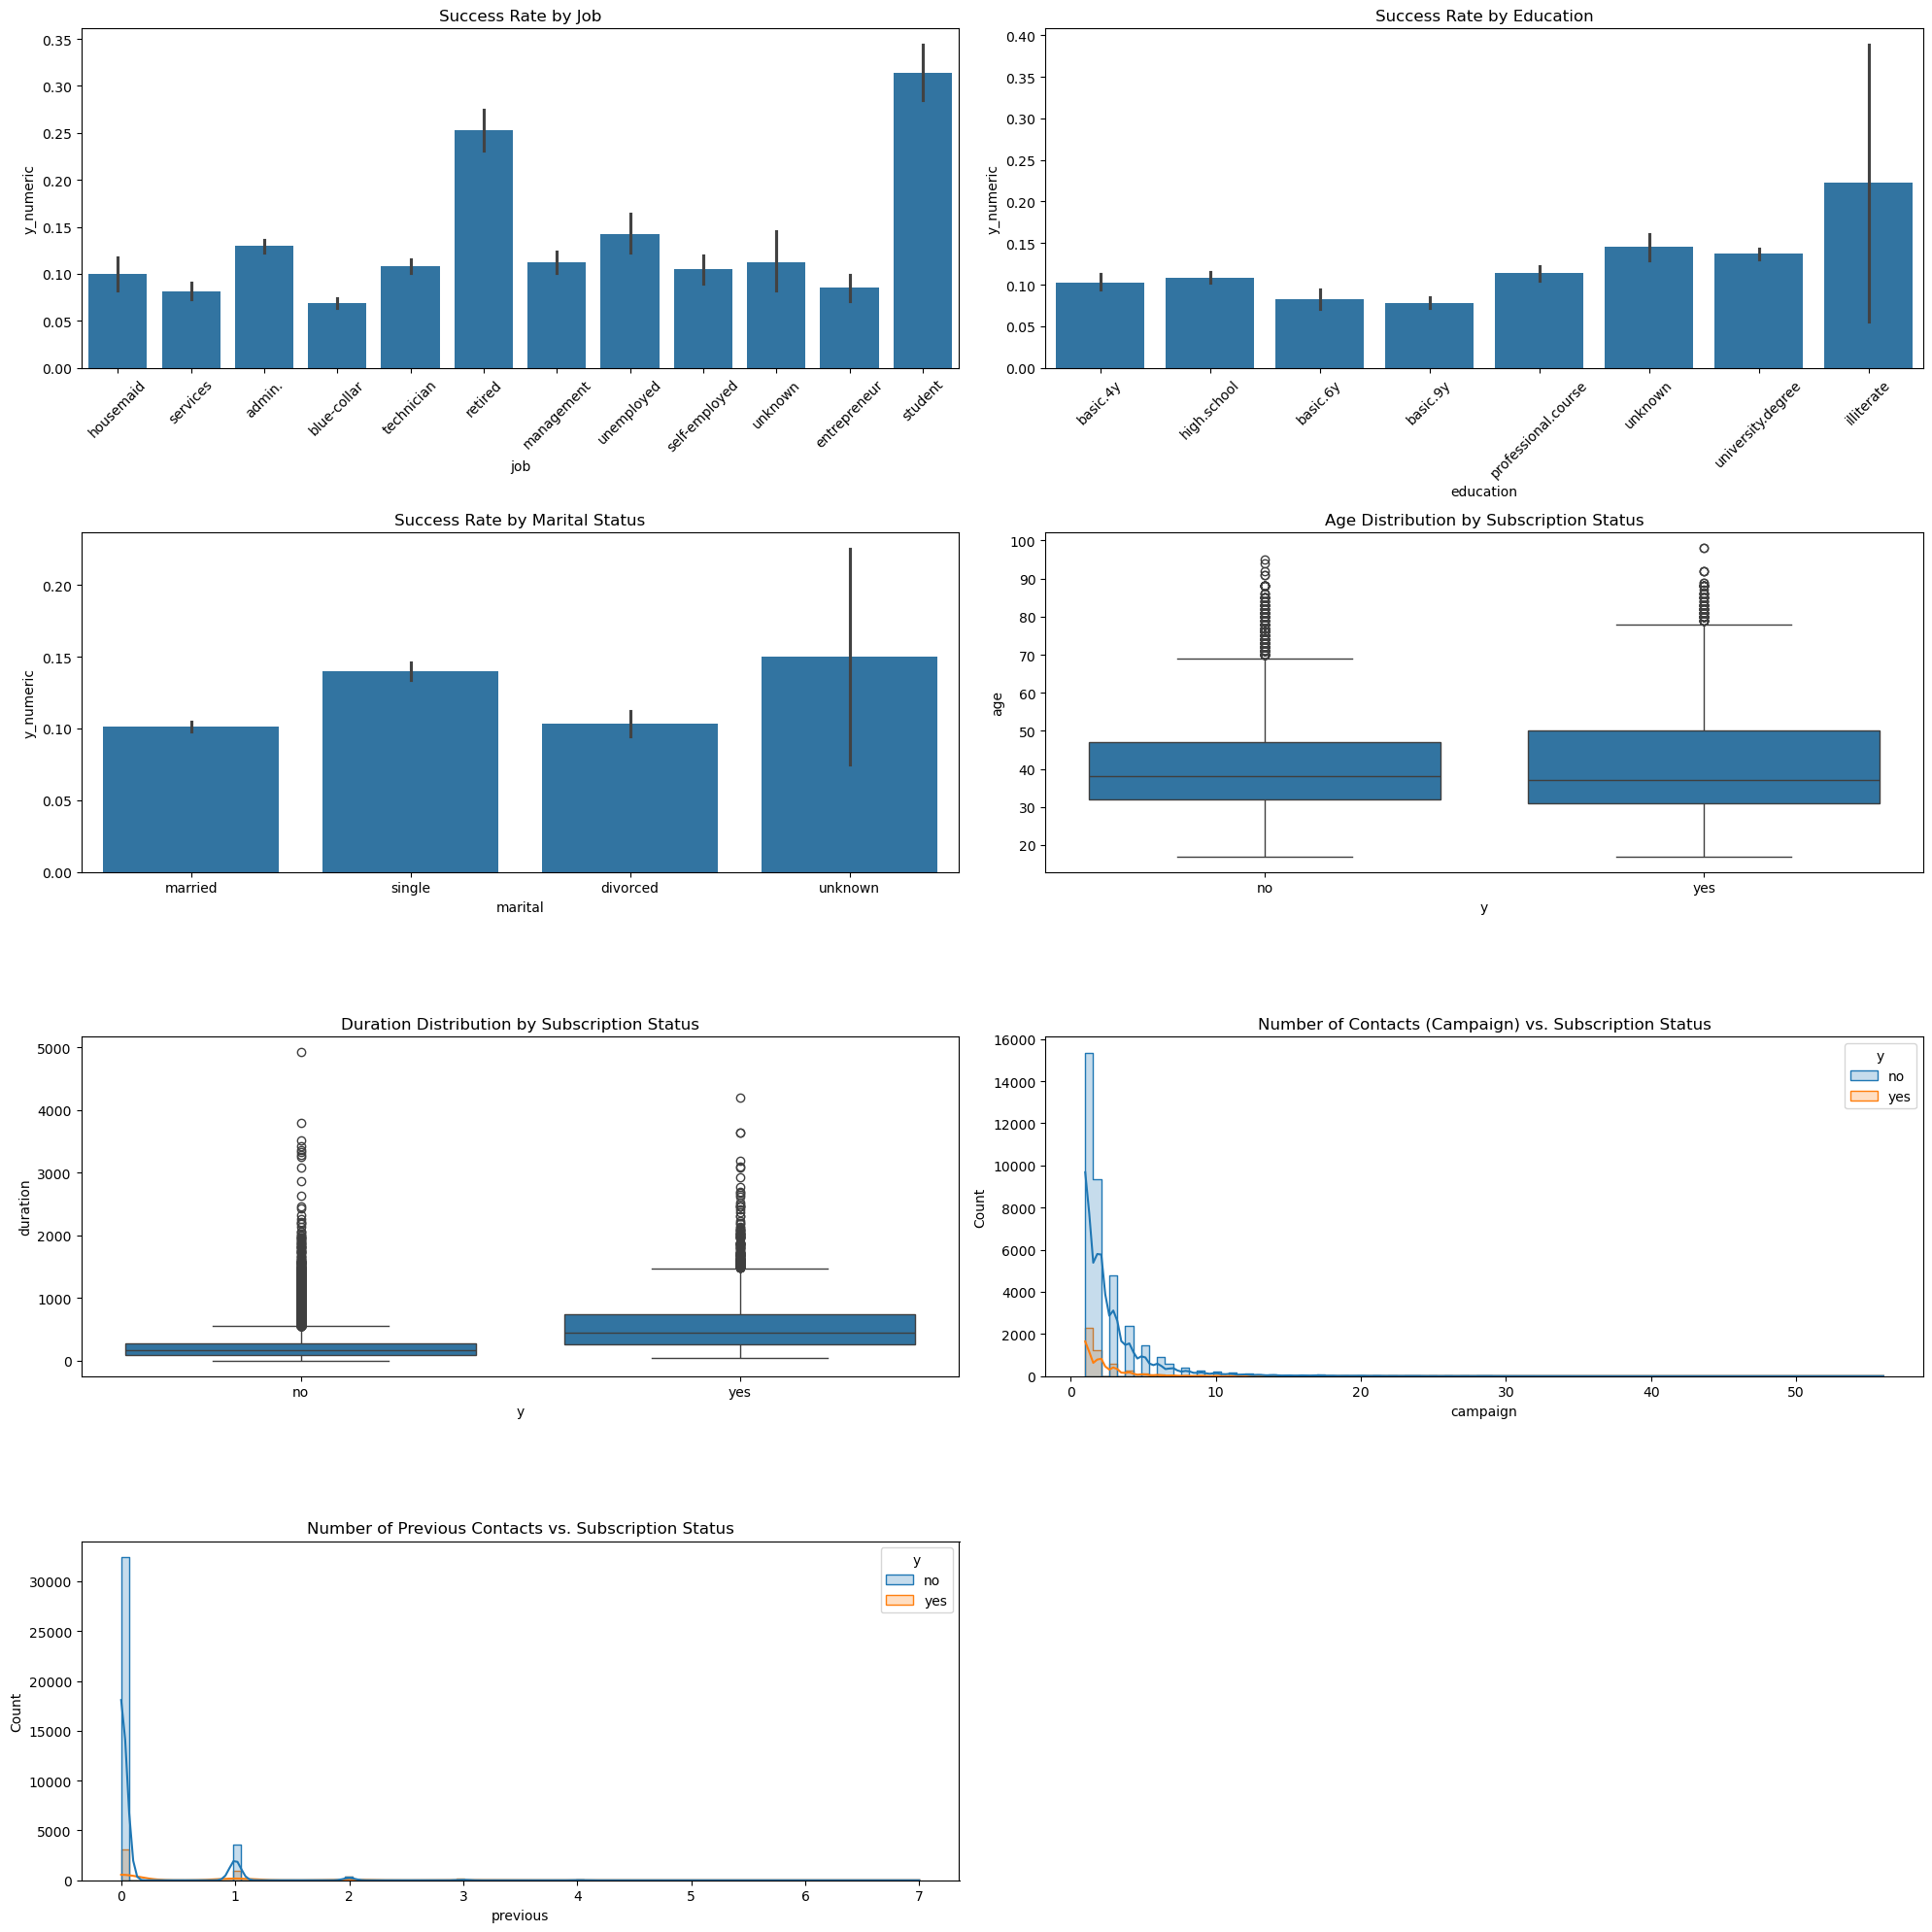

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

#Analyze the relationship between the features and the target variables
#To find the correlation between number features we can also change the categorical data of house, default and loan to integer

df_clean['housing'] = df_clean['housing'].map({'yes': 1, 'no': 0, 'unknown': -1})
df_clean['default'] = df_clean['default'].map({'yes': 1, 'no': 0, 'unknown': -1})
df_clean['loan'] = df_clean['loan'].map({'yes': 1, 'no': 0, 'unknown': -1})

# Set figure size and create subplots
fig, axes = plt.subplots(4, 2, figsize=(20, 20))  # 4 rows and 2 columns

# Success rate by job
sns.barplot(ax=axes[0, 0], x='job', y='y_numeric', data=df_clean)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_title("Success Rate by Job")

# Success rate by education
sns.barplot(ax=axes[0, 1], x='education', y='y_numeric', data=df_clean)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_title("Success Rate by Education")

# Success rate by marital status
sns.barplot(ax=axes[1, 0], x='marital', y='y_numeric', data=df_clean)
axes[1, 0].set_title("Success Rate by Marital Status")

# Age vs. Target
sns.boxplot(ax=axes[1, 1], x='y', y='age', data=df_clean)
axes[1, 1].set_title("Age Distribution by Subscription Status")

# Duration vs. Target
sns.boxplot(ax=axes[2, 0], x='y', y='duration', data=df_clean)
axes[2, 0].set_title("Duration Distribution by Subscription Status")

# Campaign calls distribution
sns.histplot(ax=axes[2, 1], data=df_clean, x='campaign', hue='y',kde=True, element='step', bins=100)
axes[2, 1].set_title("Number of Contacts (Campaign) vs. Subscription Status")

# Previous contacts distribution
sns.histplot(ax=axes[3, 0], data=df_clean, x='previous', hue='y', kde=True, element='step', bins=100)
axes[3, 0].set_title("Number of Previous Contacts vs. Subscription Status")

# Hide the empty subplot (bottom right)
axes[3, 1].axis('off')

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a single file
plt.savefig("images/multiple_plots_single_file.png")

# Show the combined figure
plt.show()


In [15]:
#Analyze the relationship between the features and the target variables
#To find the correlation between number features we can also change the categorical data of house, default and loan to integer

#df_clean['housing'] = df_clean['housing'].map({'yes': 1, 'no': 0, 'unknown': -1})
#df_clean['default'] = df_clean['default'].map({'yes': 1, 'no': 0, 'unknown': -1})
#df_clean['loan'] = df_clean['loan'].map({'yes': 1, 'no': 0, 'unknown': -1})

# Success rate by job
#sns.barplot(x='job', y=df_clean['y_numeric'], data=df_clean)
#plt.xticks(rotation=45)
#plt.title("Success Rate by Job")
#plt.show()

# Success rate by education
#sns.barplot(x='education', y=df_clean['y_numeric'], data=df_clean)
#plt.xticks(rotation=45)
#plt.title("Success Rate by Education")
#plt.show()

# Sucess rate by martiaal status
#sns.barplot(x='marital', y=df_clean['y_numeric'], data=df_clean)
#plt.title("Success Rate by Marital status")
#plt.show()


# Age vs. Target
#sns.boxplot(x='y', y='age', data=df_clean)
#plt.title("Age Distribution by Subscription Status")
#plt.show()

# Duration vs. Target
#sns.boxplot(x='y', y='duration', data=df_clean)
#plt.title("Duration Distribution by Subscription Status")
#plt.show()

# Campaign calls distribution
#sns.histplot(df_clean, x='campaign', hue='y', multiple='stack', bins=100)
#plt.title("Number of Contacts (Campaign) vs. Subscription Status")
#plt.show()

# Previous contacts distribution
#sns.histplot(df_clean, x='previous', hue='y', multiple='stack', bins=50)
#plt.title("Number of Previous Contacts vs. Subscription Status")
#plt.show()


# Save the figure as a single file
#plt.savefig("images/multiple_plots_single_file.png")

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           41176 non-null  int64  
 1   job           41176 non-null  object 
 2   marital       41176 non-null  object 
 3   education     41176 non-null  object 
 4   default       41176 non-null  int64  
 5   housing       41176 non-null  int64  
 6   loan          41176 non-null  int64  
 7   contact       41176 non-null  object 
 8   month         41176 non-null  object 
 9   day_of_week   41176 non-null  object 
 10  duration      41176 non-null  int64  
 11  campaign      41176 non-null  int64  
 12  pdays         41176 non-null  int64  
 13  previous      41176 non-null  int64  
 14  poutcome      41176 non-null  object 
 15  emp.var.rate  41176 non-null  float64
 16  euribor3m     41176 non-null  float64
 17  nr.employed   41176 non-null  float64
 18  y             41176 non-null  o

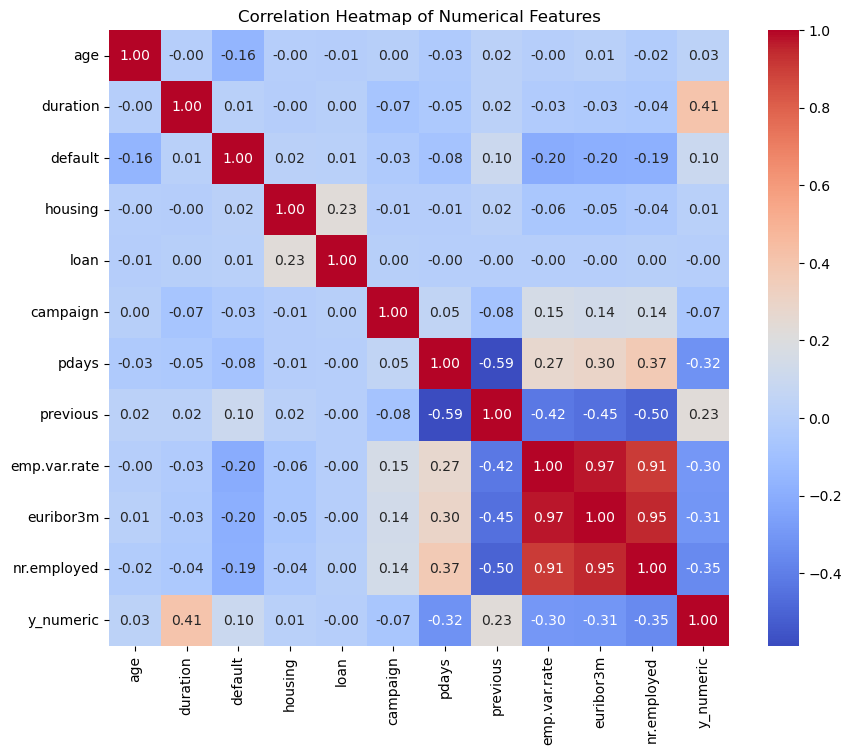

In [17]:
# Correlation heatmap
numerical_features = ['age', 'duration','default','housing','loan', 'campaign', 'pdays', 'previous', 
                      'emp.var.rate', 'euribor3m', 'nr.employed','y_numeric']
corr = df_clean[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.savefig("images/heatmap_file.png")
plt.show()



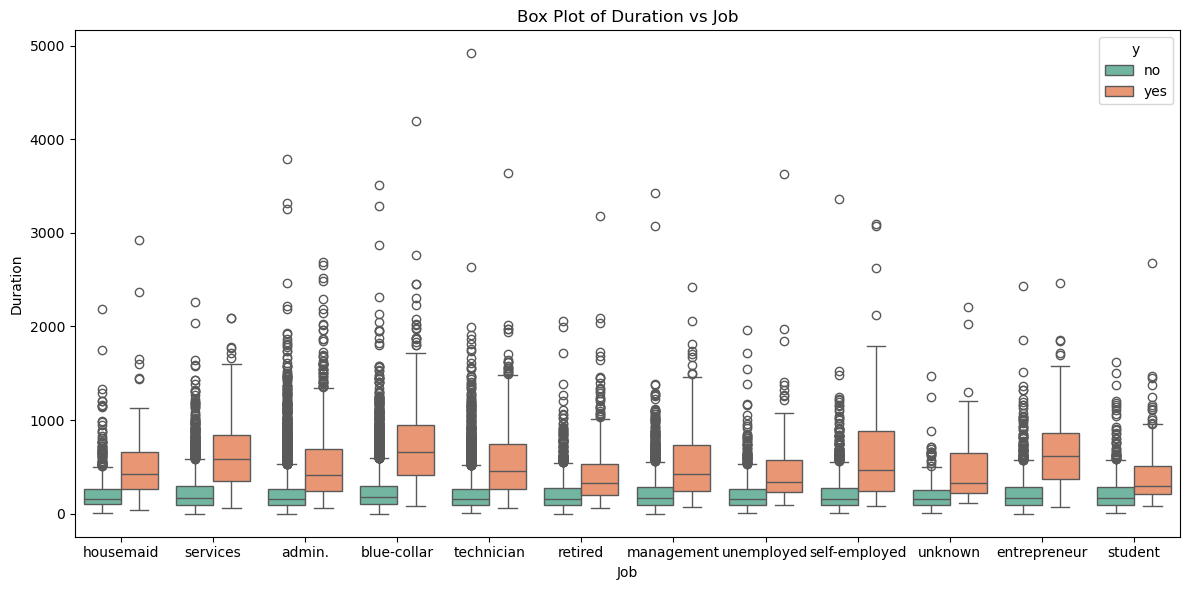

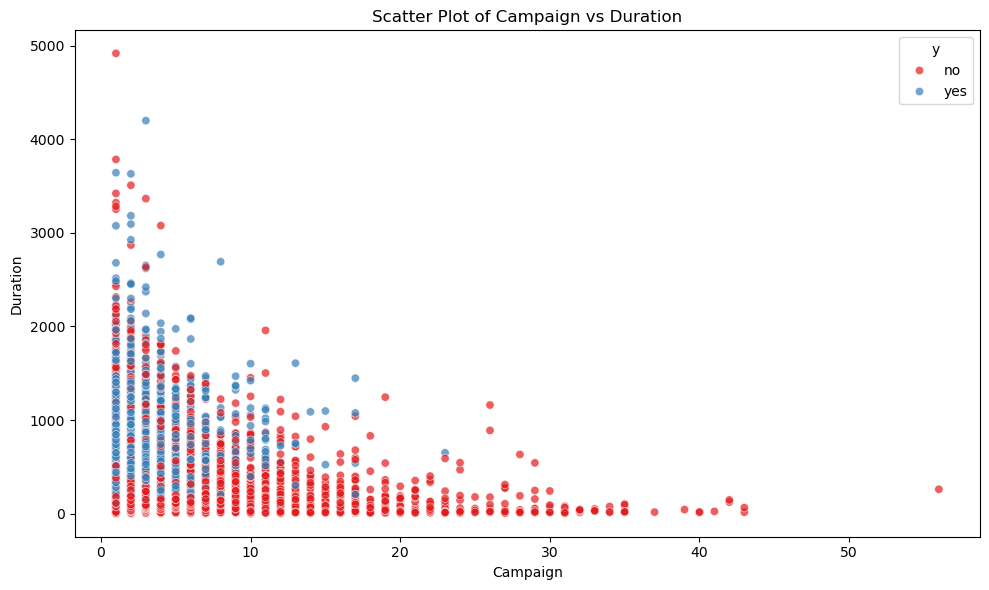

In [18]:
#Lets have some more plots 

# Box Plot for `job` vs. `duration`
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x="job", y="duration", hue="y", palette="Set2")
plt.title("Box Plot of Duration vs Job")
plt.xlabel("Job")
plt.ylabel("Duration")
plt.legend(title="y")
plt.tight_layout()
plt.savefig("images/boxplot_duration_vs_job_file.png", dpi=300)
plt.show()

# Scatter Plot for `campaign` vs. `duration`
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="campaign", y="duration", hue="y", palette="Set1", alpha=0.7)
plt.title("Scatter Plot of Campaign vs Duration")
plt.xlabel("Campaign")
plt.ylabel("Duration")
plt.legend(title="y")
plt.tight_layout()
plt.savefig("images/scatterplot_duration_vs_campaign_file.png", dpi=300)
plt.show()

In [19]:
#Based on the heatmap we can delete some of the columns that have weak relationship - like housing ,default, loan
df_clean= df_clean.drop(['default','housing','loan'], axis=1)

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The objective is to develop a data-driven predictive model that identifies 
clients/customers most likely to subscribe to the bank’s long-term deposit product based on 
demographic, behavioral, and economic context attributes. The bank can aim to optimize the strategies to 
1. Improve Campaing Effectiness ti increase the subscription success rate while reducing the customers contacts
2. Reduce overhead on operations by focusing resources on high probability clients
3. Optimize and refine the strategies by leveraging insights from data to design marketing campaigns for maximum conversions
4. Increase revenue growth by increase higher adoption for long-term deposit product

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [24]:
#Remove outliers so the model like SVM performs better,
numerical_features=['age','campaign','duration']
for cols in numerical_features:
    Q1 = df_clean[cols].quantile(0.25)
    Q3 = df_clean[cols].quantile(0.75)
    IQR = Q3 - Q1     

    filter = (df_clean[cols] >= Q1 - 1.5 * IQR) & (df_clean[cols] <= Q3 + 1.5 *IQR)
    df_clean=df_clean.loc[filter]


In [25]:
#Convert the categorical data to encoding
# Perform one-hot encoding
categorical_features=['job', 'marital', 'education', 'poutcome','contact']

for field in categorical_features:
    encoded_field = pd.get_dummies(df_clean[field], prefix=field).astype(int)
    df_clean = pd.concat([df_clean, encoded_field], axis=1)

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 35550 entries, 0 to 41186
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            35550 non-null  int64  
 1   job                            35550 non-null  object 
 2   marital                        35550 non-null  object 
 3   education                      35550 non-null  object 
 4   contact                        35550 non-null  object 
 5   month                          35550 non-null  object 
 6   day_of_week                    35550 non-null  object 
 7   duration                       35550 non-null  int64  
 8   campaign                       35550 non-null  int64  
 9   pdays                          35550 non-null  int64  
 10  previous                       35550 non-null  int64  
 11  poutcome                       35550 non-null  object 
 12  emp.var.rate                   35550 non-null  floa

In [26]:
#lets convert the month and days_of_week 
month_dict = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 
              'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
day_dict = {'sun': 1, 'mon': 2, 'tue': 3, 'wed': 4, 'thu': 5, 'fri': 6, 'sat': 7}

# Ensure all values in 'month' and 'day_of_week' columns are strings
df_clean['month'] = df_clean['month'].astype(str).str.strip().str.lower().map(month_dict).fillna(0)
df_clean['day_of_week'] = df_clean['day_of_week'].astype(str).str.strip().str.lower().map(day_dict).fillna(0)

# Replace pdays == 999 with 0
df_clean.loc[df_clean['pdays'] == 999, 'pdays'] = 0
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35550 entries, 0 to 41186
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            35550 non-null  int64  
 1   job                            35550 non-null  object 
 2   marital                        35550 non-null  object 
 3   education                      35550 non-null  object 
 4   contact                        35550 non-null  object 
 5   month                          35550 non-null  int64  
 6   day_of_week                    35550 non-null  int64  
 7   duration                       35550 non-null  int64  
 8   campaign                       35550 non-null  int64  
 9   pdays                          35550 non-null  int64  
 10  previous                       35550 non-null  int64  
 11  poutcome                       35550 non-null  object 
 12  emp.var.rate                   35550 non-null  floa

In [27]:
print(df_clean.isnull().sum())
print(df_clean.isnull().mean() * 100)

age                              0
job                              0
marital                          0
education                        0
contact                          0
month                            0
day_of_week                      0
duration                         0
campaign                         0
pdays                            0
previous                         0
poutcome                         0
emp.var.rate                     0
euribor3m                        0
nr.employed                      0
y                                0
y_numeric                        0
job_admin.                       0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown         

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [29]:
#Splitting data into training and test data

X = df_clean.select_dtypes(include=['int','float'])
X = X.drop(['y_numeric'], axis=1)

y = df_clean['y_numeric']  # Target variable (price)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [30]:
X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 35550 entries, 0 to 41186
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            35550 non-null  int64  
 1   month                          35550 non-null  int64  
 2   day_of_week                    35550 non-null  int64  
 3   duration                       35550 non-null  int64  
 4   campaign                       35550 non-null  int64  
 5   pdays                          35550 non-null  int64  
 6   previous                       35550 non-null  int64  
 7   emp.var.rate                   35550 non-null  float64
 8   euribor3m                      35550 non-null  float64
 9   nr.employed                    35550 non-null  float64
 10  job_admin.                     35550 non-null  int32  
 11  job_blue-collar                35550 non-null  int32  
 12  job_entrepreneur               35550 non-null  int3

In [31]:
##Lets create metrics List for all the models
metrics_data = []

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [58]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import time

# Ensure X_train, X_test, y_train, y_test are properly defined
# Initialize Dummy Classifier with the desired strategy
dummy_clf = DummyClassifier(strategy='stratified') 

#dummy_clf = RandomForestClassifier()
# Measure execution time
basic_start_time = time.time()
dummy_clf.fit(X_train, y_train)
basic_end_time = time.time()

# Predictions
basic_train_preds = dummy_clf.predict(X_train) 
basic_test_preds = dummy_clf.predict(X_test)

# Calculate execution time
basic_execution_time = basic_end_time - basic_start_time
print(f"Total execution time: {basic_execution_time:.2f} seconds")

# Evaluate and print metrics
print(f"Accuracy for train baseline classifier: {dummy_clf.score(X_train, y_train):.4f}")
print(f"Accuracy for test baseline classifier: {dummy_clf.score(X_test, y_test):.4f}")

print(f"Train Precision for Dummy Classifier: {precision_score(y_train, basic_train_preds, average='binary'):.4f}")
print(f"Test Precision for Dummy Classifier: {precision_score(y_test, basic_test_preds, average='binary'):.4f}")

print(f"Train Recall for Dummy Classifier: {recall_score(y_train, basic_train_preds, average='binary'):.4f}")
print(f"Test Recall for Dummy Classifier: {recall_score(y_test, basic_test_preds, average='binary'):.4f}")

print(f"Train F1-Score for Dummy Classifier: {f1_score(y_train, basic_train_preds, average='binary'):.4f}")
print(f"Test F1-Score for Dummy Classifier: {f1_score(y_test, basic_test_preds, average='binary'):.4f}")

metrics_data.append({
    "model_name": "DummyClassifier(baseline)",
    "execution_time": basic_execution_time,
    "train_accuracy": dummy_clf.score(X_train, y_train),
    "train_precision": precision_score(y_train, basic_train_preds, average='binary'),
    "train_recall": recall_score(y_train, basic_train_preds, average='binary'),
    "train_f1_score": f1_score(y_train, basic_train_preds, average='binary'),
    "test_accuracy": dummy_clf.score(X_test, y_test),
    "test_precision": precision_score(y_test, basic_test_preds, average='binary'),
    "test_recall": recall_score(y_test, basic_test_preds, average='binary'),
    "test_f1_score": f1_score(y_test, basic_test_preds, average='binary')
})

Total execution time: 0.00 seconds
Accuracy for train baseline classifier: 0.8498
Accuracy for test baseline classifier: 0.8531
Train Precision for Dummy Classifier: 0.0714
Test Precision for Dummy Classifier: 0.0785
Train Recall for Dummy Classifier: 0.0728
Test Recall for Dummy Classifier: 0.0798
Train F1-Score for Dummy Classifier: 0.0721
Test F1-Score for Dummy Classifier: 0.0791


In [60]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

start_time = time.time()
svc_clf = SVC(kernel='linear', class_weight='balanced', random_state=42).fit(X_train, y_train)
end_time= time.time()

svc_pred_train = svc_clf.predict(X_train)
svc_pred_test = svc_clf.predict(X_test)

print(f"Accuracy for baseline SVC Train {svc_clf.score(X_train,y_train)}")
print(f"Accuracy for baseline SVC Test {svc_clf.score(X_test,y_test)}")

print(f"Train Precision for SVC Classifier: {precision_score(y_train, svc_pred_train, average='binary'):.4f}")
print(f"Test Precision for SVC Classifier: {precision_score(y_test, svc_pred_test, average='binary'):.4f}")

print(f"Train Recall for SVC Classifier: {recall_score(y_train, svc_pred_train, average='binary'):.4f}")
print(f"Test Recall for SVC Classifier: {recall_score(y_test, svc_pred_test, average='binary'):.4f}")

print(f"Train F1-Score for SVC Classifier: {f1_score(y_train, svc_pred_train, average='binary'):.4f}")
print(f"Test F1-Score for SVC Classifier: {f1_score(y_test, svc_pred_test, average='binary'):.4f}")

metrics_data.append({
    "model_name": "SVC(baseline)",
    "execution_time": end_time - start_time,
    "train_accuracy": svc_clf.score(X_train,y_train),
    "train_precision": precision_score(y_train, svc_pred_train, average='binary'),
    "train_recall": recall_score(y_train, svc_pred_train, average='binary'),
    "train_f1_score": f1_score(y_train, svc_pred_train, average='binary'),
    "test_accuracy": svc_clf.score(X_test,y_test),
    "test_precision": precision_score(y_test, svc_pred_test, average='binary'),
    "test_recall": recall_score(y_test, svc_pred_test, average='binary'),
    "test_f1_score": f1_score(y_test, svc_pred_test, average='binary')
})

Accuracy for baseline SVC Train 0.90014064697609
Accuracy for baseline SVC Test 0.8992030004688233
Train Precision for SVC Classifier: 0.4278
Test Precision for SVC Classifier: 0.4236
Train Recall for SVC Classifier: 0.6840
Test Recall for SVC Classifier: 0.6728
Train F1-Score for SVC Classifier: 0.5264
Test F1-Score for SVC Classifier: 0.5199


The mode that we want to build should have accuracy above 89% 

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [62]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

lg_start_time = time.time()
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

#log_reg = LogisticRegression(max_iter=1000, random_state=42) 
log_reg = GradientBoostingClassifier(n_estimators=100, random_state=42)
log_reg.fit(X_train_scaled, y_train)

lg_end_time = time.time()
log_reg_train_preds = log_reg.predict(X_train_scaled) 
log_reg_test_preds = log_reg.predict(X_test_scaled)

log_reg_train_accuracy = accuracy_score(y_train, log_reg_train_preds) 
log_reg_train_precision = precision_score(y_train, log_reg_train_preds) 
log_reg_train_recall = recall_score(y_train, log_reg_train_preds) 
log_reg_train_f1 = f1_score(y_train, log_reg_train_preds)

log_reg_test_accuracy = accuracy_score(y_test, log_reg_test_preds) 
log_reg_test_precision = precision_score(y_test, log_reg_test_preds) 
log_reg_test_recall = recall_score(y_test, log_reg_test_preds) 
log_reg_test_f1 = f1_score(y_test, log_reg_test_preds)

execution_time_lg =  lg_end_time -lg_start_time 
print(f"Total execution time: {execution_time_lg:.2f} seconds")
print(f"Logistic Regression Train Accuracy: {log_reg_train_accuracy:.4f}") 
print(f"Logistic Regression Test Accuracy: {log_reg_test_accuracy:.4f}")

print(f"Train Precision for Logictics Regression: {log_reg_train_precision}") 
print(f"Test Precision for Logictics Regression: {log_reg_test_precision}")

print(f"TrainRecall for Logictics Regression: {log_reg_train_recall}") 
print(f"Test Recall for Logictics Regression: {log_reg_test_recall}")

print(f"Train F1-Score for Logictics Regression: {log_reg_train_f1}") 
print(f"Test F1-Score for Logictics Regression: {log_reg_test_f1}")

print("\nClassification Report:") 
print(classification_report(y_test, log_reg_test_preds))

Total execution time: 3.57 seconds
Logistic Regression Train Accuracy: 0.9452
Logistic Regression Test Accuracy: 0.9375
Train Precision for Logictics Regression: 0.7193569993302076
Test Precision for Logictics Regression: 0.6504559270516718
TrainRecall for Logictics Regression: 0.5319465081723626
Test Recall for Logictics Regression: 0.49479768786127165
Train F1-Score for Logictics Regression: 0.6116173120728929
Test F1-Score for Logictics Regression: 0.562048588312541

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      9800
           1       0.65      0.49      0.56       865

    accuracy                           0.94     10665
   macro avg       0.80      0.74      0.76     10665
weighted avg       0.93      0.94      0.93     10665



In [64]:
metrics_data.append({
    "model_name": "LogisticRegression(default)",
    "execution_time": execution_time_lg,
    "train_accuracy": log_reg_train_accuracy,
    "train_precision": log_reg_train_precision,
    "train_recall": log_reg_train_recall ,
    "train_f1_score": log_reg_train_f1 ,
    "test_accuracy": log_reg_test_accuracy,
    "test_precision": log_reg_test_precision,
    "test_recall": log_reg_test_recall,
    "test_f1_score": log_reg_test_f1
})

### Problem 9: Score the Model

What is the accuracy of your model?

Accuracy of the simple logictics Regression is around 94% 

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

#ecisionTree (default)	DecisionTreeClassifier(max_depth=1, criterion='gini')
#KNN	KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')
#SVM	SVC(C=1.0, kernel='rbf', gamma='scale', probability=True)

models = {
    'DecisionTree(Default)': {
        'model': DecisionTreeClassifier(random_state=42)
    },
    'KNeighbors(Default)': {
        'model': KNeighborsClassifier(n_neighbors=5)
    },
    'SVM(Default)': {
        'model': SVC(random_state=42)
  }
}


print(f" Model	                           |            Train Time	        |           Train Accuracy	        |        Test Accuracy       |")
print(f" Logistic Regression	           |     {execution_time_lg}        |        {log_reg_train_accuracy}	|  {log_reg_test_accuracy}   |")

X = df_clean.select_dtypes(include=['int','float'])
X = X.drop(['y_numeric'], axis=1)

y = df_clean['y_numeric']  # Target variable (price)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for model_name, model_details in models.items():
    print(f"\nRunning GridSearchCV for {model_name}, {model_details}...")

    start_time = time.time()

    # Initialize AdaBoost with the selected model as the base estimator
    # ada_boost = AdaBoostClassifier(estimator=model_details['model'], n_estimators=50, random_state=42)

     # Create a pipeline with scaling and AdaBoost model
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # Apply scaling
        ('model', model_details['model'])  # Add the model dynamically
    ])

    # Grid Search with 5-fold cross-validation (this time no need for param_grid as base_estimator is set)
    grid = GridSearchCV(
        pipeline, 
        param_grid={},  # You can specify other hyperparameters here for the AdaBoost or base estimator
        cv=5, 
        scoring='roc_auc', 
        verbose=0
    )

    # Fit the grid search
    grid.fit(X_train, y_train)

    # Best parameters and model performance
    #print(f"Best Parameters for {model_name}: {grid_log_reg.best_params_}")
    #print(f"Best Cross-Validation Accuracy for {model_name}: {grid_log_reg.best_score_}")
    
    # Evaluate the best model on the test set
    #best_model = grid_log_reg.best_estimator_
    #y_pred = best_model.predict(X_test)

    end_time = time.time()
    train_preds = grid.predict(X_train) 
    test_preds = grid.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds) 
    train_precision = precision_score(y_train, train_preds) 
    train_recall = recall_score(y_train, train_preds) 
    train_f1 = f1_score(y_train, train_preds)

    test_accuracy = accuracy_score(y_test, test_preds) 
    test_precision = precision_score(y_test, test_preds) 
    test_recall = recall_score(y_test, test_preds) 
    test_f1 = f1_score(y_test, test_preds)

    execution_time =  end_time - start_time 
    print(f" model - {model_name}")
    print(f" execution time - {execution_time}")
    print(f" accuracy train - {train_accuracy} , accuracy test -  {test_accuracy}")
    print(f" precision train - {train_precision} , precision test -  {test_precision}")
    print(f" recall train - {train_recall} , recall test -  {test_recall}")
    print(f" F1-score train - {train_f1} ,  F1-score test -  {test_f1}")
    
    metrics_data.append({
    "model_name": model_name,
    "execution_time": execution_time,
    "train_accuracy": train_accuracy,
    "train_precision": train_precision,
    "train_recall": train_recall ,
    "train_f1_score": train_f1 ,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1_score": test_f1
})

 Model	                           |            Train Time	        |           Train Accuracy	        |        Test Accuracy       |
 Logistic Regression	           |     3.5718905925750732        |        0.945187864175206	|  0.9374589779653071   |

Running GridSearchCV for DecisionTree(Default), {'model': DecisionTreeClassifier(random_state=42)}...
 model - DecisionTree(Default)
 execution time - 0.9131748676300049
 accuracy train - 0.9999598151496886 , accuracy test -  0.9178621659634317
 precision train - 1.0 , precision test -  0.49352051835853133
 recall train - 0.9995049504950495 , recall test -  0.5289351851851852
 F1-score train - 0.9997524139638524 ,  F1-score test -  0.5106145251396648

Running GridSearchCV for KNeighbors(Default), {'model': KNeighborsClassifier()}...
 model - KNeighbors(Default)
 execution time - 1.0471937656402588
 accuracy train - 0.9430178822583886 , accuracy test -  0.9250820440693859
 precision train - 0.7504159733777038 , precision test -  0.5687103594

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [68]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


models = {
    'LogisticRegression(Tuned)': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'model__C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
            'model__penalty': ['l2']       # Regularization type
        }
    },
   'RandonTree(Tuned)': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'KNeighbors(Tuned)': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2],  # Manhattan (1) or Euclidean (2) distance
            'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    }
}


X = df_clean.select_dtypes(include=['int','float'])
X = X.drop(['y_numeric'], axis=1)

y = df_clean['y_numeric']  # Target variable (price)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for model_name, model_details in models.items():
    print(f"\nRunning GridSearchCV for {model_name}...")
    start_time = time.time()
    
    # Create a pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # Apply scaling
        ('model', model_details['model'])  # Add the model dynamically
    ])

    # Grid Search with 5-fold cross-validation
    grid = GridSearchCV(
        pipeline, 
        param_grid=model_details['params'], 
        cv=5, 
        scoring='roc_auc', 
        verbose=0,
        error_score='raise'
    )

    # Fit the grid search
    grid.fit(X_train, y_train)

    end_time = time.time()
    
    # Best parameters and model performance
    print(f"Best Parameters for {model_name}: {grid.best_params_}")
    print(f"Best Cross-Validation Accuracy for {model_name}: {grid.best_score_}")
    
    # Evaluate the best model on the test set
    best_model = grid.best_estimator_
    
    end_time = time.time()
    train_preds = best_model.predict(X_train) 
    test_preds = best_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds) 
    train_precision = precision_score(y_train, train_preds) 
    train_recall = recall_score(y_train, train_preds) 
    train_f1 = f1_score(y_train, train_preds)

    test_accuracy = accuracy_score(y_test, test_preds) 
    test_precision = precision_score(y_test, test_preds) 
    test_recall = recall_score(y_test, test_preds) 
    test_f1 = f1_score(y_test, test_preds)

    execution_time = end_time -start_time
    metrics_data.append({
        "model_name": model_name,
        "execution_time" : execution_time,
        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall ,
        "train_f1_score": train_f1 ,
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1_score": test_f1
    })

    
    print(f" {model_name}      |     {execution_time}        |        {train_accuracy}	|  {test_accuracy}   |")
    print(f" {train_precision} |  {test_precision} | {train_recall} | {test_recall} | {train_f1} | {test_f1} |")


Running GridSearchCV for LogisticRegression(Tuned)...
Best Parameters for LogisticRegression(Tuned): {'model__C': 100, 'model__penalty': 'l2'}
Best Cross-Validation Accuracy for LogisticRegression(Tuned): 0.9321044962576293
 LogisticRegression(Tuned)      |     16.0193133354187        |        0.9351818364476593	|  0.929676511954993   |
 0.6666666666666666 |  0.611328125 | 0.402970297029703 | 0.36226851851851855 | 0.5023141005862388 | 0.45494186046511625 |

Running GridSearchCV for RandonTree(Tuned)...
Best Parameters for RandonTree(Tuned): {'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best Cross-Validation Accuracy for RandonTree(Tuned): 0.951164930619456
 RandonTree(Tuned)      |     614.5332937240601        |        0.960337552742616	|  0.936896390060947   |
 0.8909916729750189 |  0.6778398510242085 | 0.5826732673267326 | 0.4212962962962963 | 0.7045794672253817 | 0.5196288365453248 |

Running GridSearchCV for KN

In [70]:
models = {
      'SVM(tuned)': {
        'model': SVC(random_state=42),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['rbf'],
            'model__gamma': ['auto'],
            'model__class_weight': [None, 'balanced']
        }
    }
}

X = df_clean.select_dtypes(include=['int','float'])
X = X.drop(['y_numeric'], axis=1)

y = df_clean['y_numeric']  # Target variable (price)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for model_name, model_details in models.items():
    print(f"\nRunning GridSearchCV for {model_name}...")
    start_time = time.time()
    
    # Create a pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # Apply scaling
        ('model', model_details['model'])  # Add the model dynamically
    ])

    # Grid Search with 5-fold cross-validation
    grid = GridSearchCV(
        pipeline, 
        param_grid=model_details['params'], 
        cv=5, 
        scoring='roc_auc', 
        verbose=0,
        error_score='raise'
    )

    # Fit the grid search
    grid.fit(X_train, y_train)

    end_time = time.time()
    
    # Best parameters and model performance
    print(f"Best Parameters for {model_name}: {grid.best_params_}")
    print(f"Best Cross-Validation Accuracy for {model_name}: {grid.best_score_}")
    
    # Evaluate the best model on the test set
    best_model = grid.best_estimator_
    
    end_time = time.time()
    train_preds = best_model.predict(X_train) 
    test_preds = best_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds) 
    train_precision = precision_score(y_train, train_preds) 
    train_recall = recall_score(y_train, train_preds) 
    train_f1 = f1_score(y_train, train_preds)

    test_accuracy = accuracy_score(y_test, test_preds) 
    test_precision = precision_score(y_test, test_preds) 
    test_recall = recall_score(y_test, test_preds) 
    test_f1 = f1_score(y_test, test_preds)

    execution_time = end_time -start_time

    metrics_data.append({
        "model_name": model_name,
        "execution_time" : execution_time,
        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall ,
        "train_f1_score": train_f1 ,
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1_score": test_f1
    })

    print(f" {model_name}      |     {execution_time}        |        {train_accuracy}	|  {test_accuracy}   |")
    print(f" {train_precision} |  {test_precision} | {train_recall} | {test_recall} | {train_f1} | {test_f1} |")


Running GridSearchCV for SVM(tuned)...
Best Parameters for SVM(tuned): {'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best Cross-Validation Accuracy for SVM(tuned): 0.9291764186258993
 SVM(tuned)      |     412.32478737831116        |        0.8709664456499899	|  0.8501640881387716   |
 0.3827986616807715 |  0.335573476702509 | 0.9628712871287128 | 0.8668981481481481 | 0.5478101675820307 | 0.4838501291989664 |


In [74]:
df_metrics = pd.DataFrame(metrics_data)

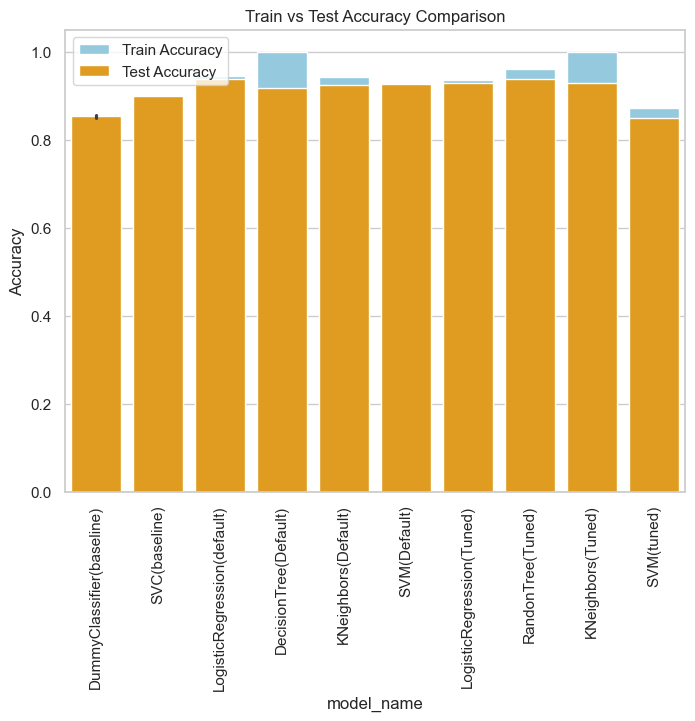

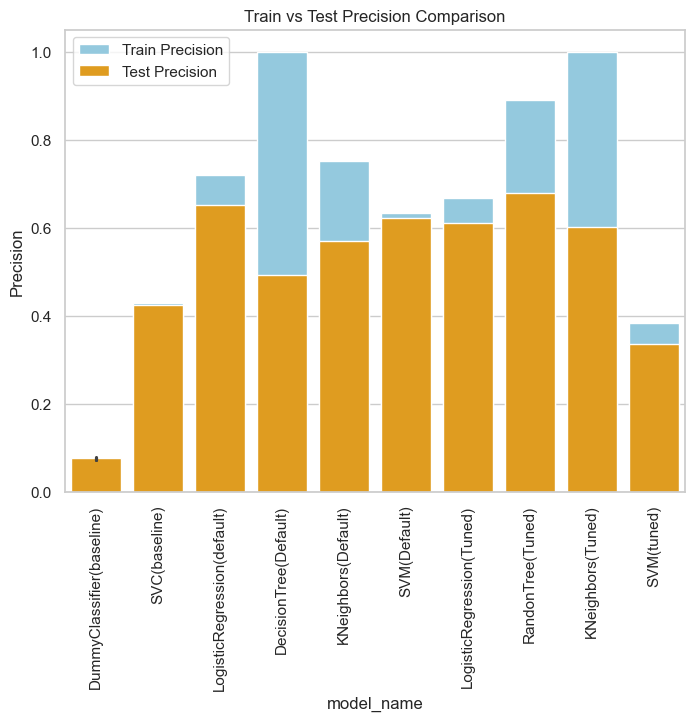

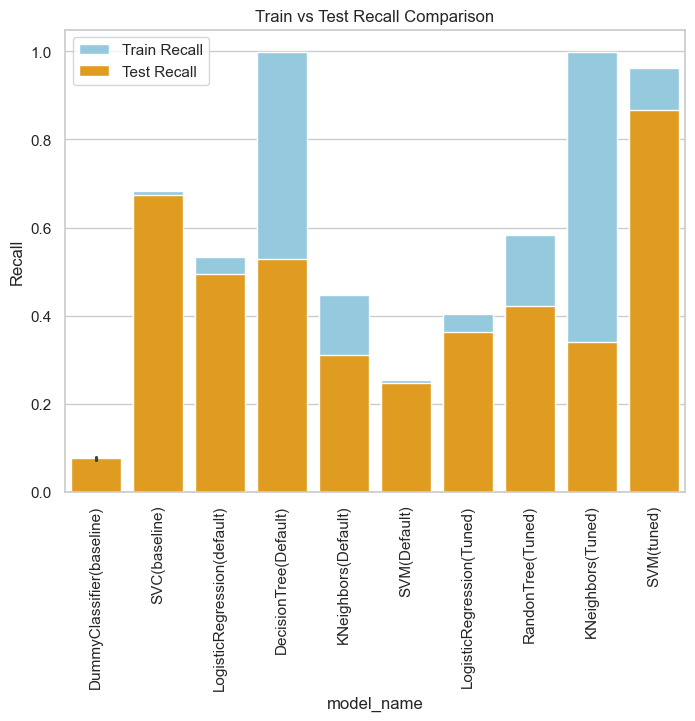

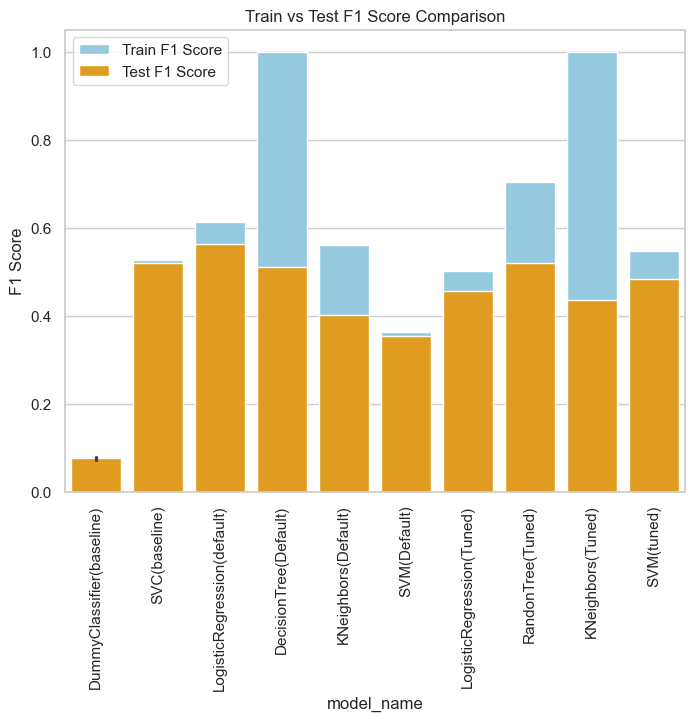

In [76]:
# Set plot style
sns.set(style="whitegrid")

# 1. Accuracy comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_accuracy", data=df_metrics, color="skyblue", label="Train Accuracy")
sns.barplot(x="model_name", y="test_accuracy", data=df_metrics, color="orange", label="Test Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_Accuracy_for_models.png", dpi=300)
plt.show()

# 2. Precision comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_precision", data=df_metrics, color="skyblue", label="Train Precision")
sns.barplot(x="model_name", y="test_precision", data=df_metrics, color="orange", label="Test Precision")
plt.title("Train vs Test Precision Comparison")
plt.ylabel("Precision")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_Precision_for_models.png", dpi=300)
plt.show()

# 3. Recall comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_recall", data=df_metrics, color="skyblue", label="Train Recall")
sns.barplot(x="model_name", y="test_recall", data=df_metrics, color="orange", label="Test Recall")
plt.title("Train vs Test Recall Comparison")
plt.ylabel("Recall")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_Recall_for_models.png", dpi=300)
plt.show()

# 4. F1 Score comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_f1_score", data=df_metrics, color="skyblue", label="Train F1 Score")
sns.barplot(x="model_name", y="test_f1_score", data=df_metrics, color="orange", label="Test F1 Score")
plt.title("Train vs Test F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_F1Score_for_models.png", dpi=300)
plt.show()


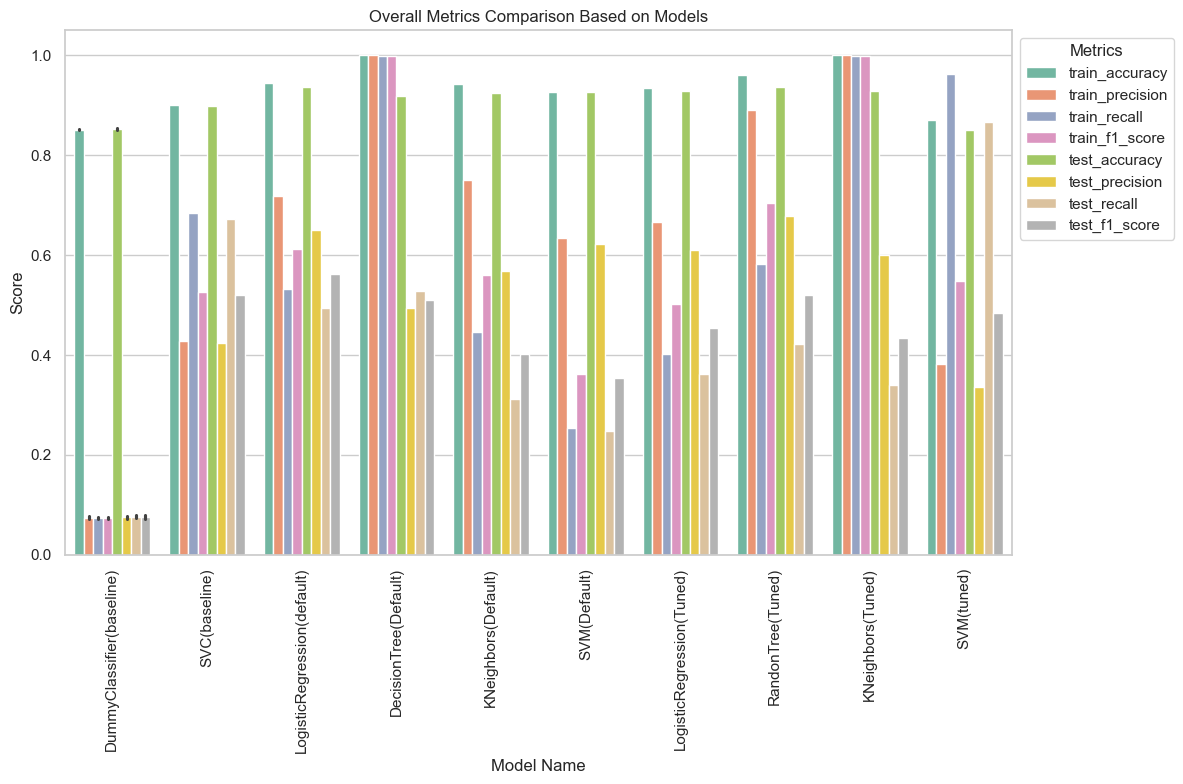

In [78]:
# Set plot style
sns.set(style="whitegrid")

# Reshape the data for plotting (melt the DataFrame)
df_melted = df_metrics.melt(id_vars=["model_name"], 
                            value_vars=["train_accuracy", "train_precision", "train_recall", "train_f1_score", 
                                        "test_accuracy", "test_precision", "test_recall", "test_f1_score"],
                            var_name="metric", value_name="score")

# Create a combined plot for overall metrics based on the models
plt.figure(figsize=(12, 8))
sns.barplot(x="model_name", y="score", hue="metric", data=df_melted, palette="Set2")

# Customize the plot
plt.title("Overall Metrics Comparison Based on Models")
plt.ylabel("Score")
plt.xlabel("Model Name")
plt.xticks(rotation=90)
plt.legend(title="Metrics", loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig("images/barplot_for_overall_model_metrics.png", dpi=300)
# Display the plot
plt.tight_layout()
plt.show()

##### Questions